In [ ]:
!pip install scanpy squidpy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import

In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

Using CPU


In [4]:
##Working with google colab
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d")
cwd = os.getcwd()
print(cwd)
sys.path.append("../")

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d


In [5]:
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import spatialdata as sd
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics
from sklearn.preprocessing import Normalizer, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

/usr/local/lib/python3.12/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'DejaVu Sans'

pltkw = dict(bbox_inches='tight', transparent=True)

In [7]:
import importlib
import steamboat_m_integrated_1_d as sf
import steamboat_m_integrated_1_d.tools
import steamboat_m_integrated_1_d.model

In [8]:
importlib.reload(sf)
importlib.reload(sf.tools)
importlib.reload(sf.model)

<module 'steamboat_m_integrated_1_d.model' from '/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d/../steamboat_m_integrated_1_d/model.py'>

## Head weights

In [21]:
s_path = "/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/ann_data.zarr"
sdata = sd.read_zarr(s_path)

In [9]:
adata = sc.read_h5ad("../../Data/Breast_Cancer/ann_data.h5ad")

Foundation Models

In [ ]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/h_optimus.h5ad")
M = edata.obsm['h_optimus']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [10]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI.h5ad")
M = edata.obsm['UNI']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [ ]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/virchow.h5ad")
M = edata.obsm['virchow']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [11]:
edata.obs_names = [str(int(cid[63:])-1) for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['UNI'][edata.obs_names.get_indexer(common_cells)]

In [12]:
#normalizer = Normalizer(norm="l2")
#ad.obsm['morpho'] = normalizer.transform(ad.obsm['morpho'])

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho'] - np.min(ad.obsm['morpho'])

ROI Seperation

In [ ]:
edata = sc.read_h5ad("../../Data/Breast_Cancer/FMs_1/omiCLIP.h5ad")
N = edata.obsm['Omi_Clip'].astype(np.float32).copy()

In [ ]:
np.random.seed(42)

n = N.shape[1]
means = [0.0, 3.0, 6.0, 9.0]
std = 1.0

# generate vectors
v1 = np.random.normal(means[0], std, n)
v2 = np.random.normal(means[1], std, n)
v3 = np.random.normal(means[2], std, n)
v4 = np.random.normal(means[3], std, n)

# stack for joint normalization
V = np.vstack([v1, v2, v3, v4])

# normalize using global mean and std (preserves relative differences)
global_mean = V.mean()
global_std = V.std()

V_norm = (V - global_mean) / global_std

v1_norm, v2_norm, v3_norm, v4_norm = V_norm

In [ ]:
adata.obsm['p_Morpho_Embedding'] = np.zeros_like(N)
mask1 = adata.obs['annotation'] == 'DCIS_1'
mask2 = adata.obs['annotation'] == 'DCIS_2'
mask3 = adata.obs['annotation'] == 'Invasive'
mask4 = adata.obs['annotation'] == 'unassigned'
adata.obsm['p_Morpho_Embedding'][mask1] = v1_norm
adata.obsm['p_Morpho_Embedding'][mask2] = v2_norm
adata.obsm['p_Morpho_Embedding'][mask3] = v3_norm
adata.obsm['p_Morpho_Embedding'][mask4] = v4_norm

Cell_Type Separation

In [ ]:
E = np.random.normal(len(adata.obs['cell_type'].unique()), N.shape[1])
normalizer = Normalizer(norm="l2")
E = normalizer.transform(E)

In [ ]:
adata.obsm['p_Morpho_Embedding'] = np.zeros((adata.shape[0], N.shape[1]))
for (i, c_type) in enumerate(adata.obs['cell_type'].unique()):
    mask = adata.obs['cell_type'] == c_type
    adata.obsm['p_Morpho_Embedding'][mask] = E[i]

Noise

In [ ]:
E = np.random.normal(N.shape)
normalizer = Normalizer(norm="l2")
adata.obsm['p_Morpho_Embedding'] = normalizer.transform(E)

Head Weights

In [13]:
adatas = []
for i in adata.obs['region'].unique():
    adatas.append(adata[adata.obs['region'] == i])
    adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.

/tmp/ipython-input-4759537.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.


In [14]:
adatas = sf.prep_adatas(adatas, norm=True, log1p=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
model = sf.Steamboat(adatas[0].var_names.tolist(), Morpho_features = adata.obsm['p_Morpho_Embedding'].shape[1], n_heads=50, n_scales=3)
model = model.to(device)


In [ ]:
##working with google colab
model.load_state_dict(torch.load('saved_models/Xbcancer_50_0.3_hoptimus.pth', weights_only=True), strict=False)

<All keys matched successfully>

In [16]:
##working with laptop
model.load_state_dict(torch.load('saved_models/Xbcancer_50_0.3_UNI.pth', map_location=torch.device('cpu'),weights_only=True))

<All keys matched successfully>

In [ ]:
import gc
gc.collect()

72795

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:05<00:00,  5.34s/it]


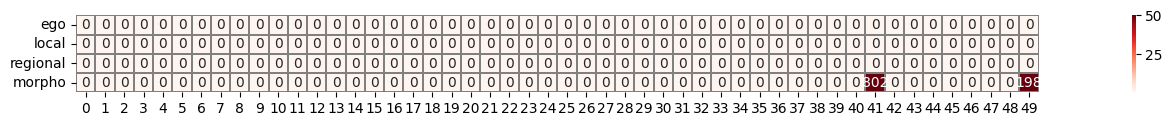

In [17]:
## For simplicity, we only visualize the weights from one slide here, not all of them.
dataset = sf.make_dataset(adatas, regional_obs=['global'])
sf.tools.calc_obs(adatas, dataset, model)
head_weights = sf.tools.calc_head_weights(device, adatas, model)
sf.tools.plot_head_weights(head_weights, figsize=(24, 1), multiplier=1000, heatmap_kwargs={'vmax': 50})

In [ ]:
for key in adatas[0].obsm.keys():
  print(key)

spatial
p_Morpho_Embedding
q_score
k_morpho_score
k_score
k_score_global
attn
ego_attn
morpho_attn
local_attn
regional_attn_0


In [ ]:
l = [1, 19, 29, 29, 45]
for i_head in l: ## Change this to see more
    adatas[0].obs['a_obs'] = adatas[0].obsm['k_score'][:, i_head]
    adatas[0].obs['morpho_obs'] = adatas[0].obsm['k_morpho_score'][:, i_head]
    adatas[0].obs['q_obs'] = adatas[0].obsm['q_score'][:, i_head]
    adatas[0].obs['k_obs'] = adatas[0].obsm['k_score'][:, i_head]

    sq.pl.spatial_scatter(adatas[0],
                          color=['a_obs', 'q_obs', 'k_obs', 'morpho_obs'],
                          shape=None, figsize=(4, 2), size=0.25,
                          legend_fontsize=9, cmap='Reds', ncols=4,
                          colorbar=False, vmin=0., wspace=.0,
                          outline=False, frameon=False,
                          title=['Attention', 'Query', 'Local Key', 'morpgology']
                          )

## Clustering and spatial domain segmentaiton

In [ ]:
cell_anno_path = "/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/Cell_Barcode_Type_Matrices.xlsx"

df = pd.read_excel(cell_anno_path,
                   sheet_name="Xenium R1 Fig1-5 (supervised)"
                   )

sdata['table'].obs["cell_type"] = (
    sdata['table'].obs["cell_id"]
    .map(df.set_index("Barcode")["Cluster"])
)

In [ ]:
adatas[0].obsm.keys()

KeysView(AxisArrays with keys: spatial, p_Morpho_Embedding, attn, X_umap, q_score, q_morpho_score, k_score, k_score_global, ego_attn, local_attn, regional_attn_0)

In [18]:
!pip install igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 112.1 MB/s eta 0:00:00


In [ ]:
sf.tools.neighbors(adatas[0], 'k_morpho_score')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

In [ ]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_clusters'], title=['sc#3 clusters by morpho embeddings'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [57]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [ ]:
sf.tools.neighbors(adatas[0], 'attn')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

In [ ]:
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()

sq.pl.spatial_scatter(
    adatas[0], color=['cell_type'], title=['Annotated Cell Types'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_clusters'], title=['sc#3 clusters by attention scores'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

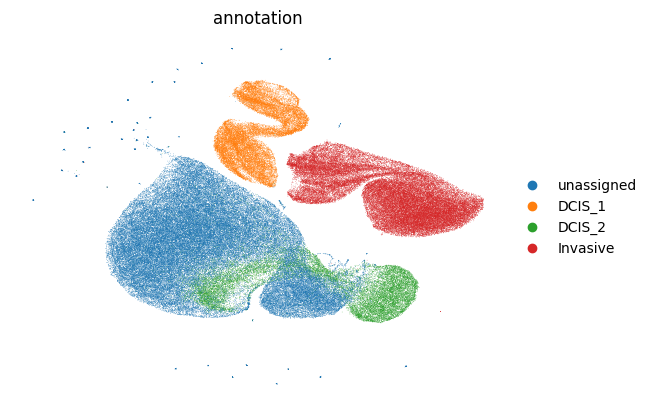

In [ ]:
ad = adata
ad.obsm["attn"] = adatas[0].obsm["morpho_attn"]

# Build neighbors using attention space
sc.pp.neighbors(ad, use_rep="attn")

# Compute UMAP
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="annotation", frameon=False)

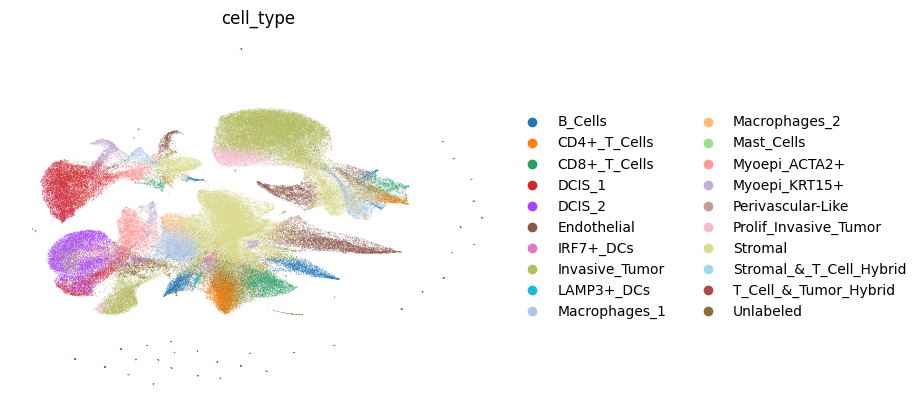

In [ ]:
ad = adata
ad.obsm["attn"] = adatas[0].obsm["attn"]

# Build neighbors using attention space
sc.pp.neighbors(ad, use_rep="attn")

# Compute UMAP
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nmi = normalized_mutual_info_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("NMI:", nmi)

ari = adjusted_rand_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("ARI:", ari)

NMI: 0.5713062764821852
ARI: 0.31825452735051507


In [ ]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [ ]:
sf.tools.neighbors(adatas[0], 'X')  #compute a neighborhood graph on genevectors
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

In [ ]:
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()

sq.pl.spatial_scatter(
    sdata['table'], color=['cell_type'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_clusters'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

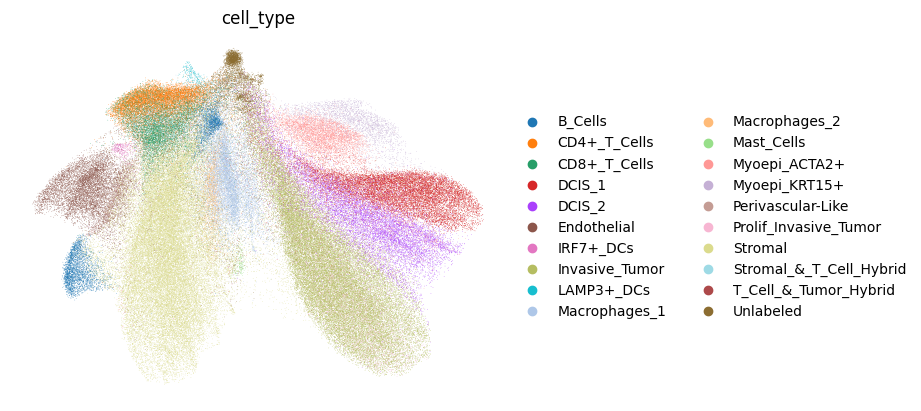

In [ ]:
ad = sdata['table']

# Build neighbors using attention space
sc.pp.neighbors(ad, use_rep="X")

# Compute UMAP
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nmi = normalized_mutual_info_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("NMI:", nmi)

ari = adjusted_rand_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("ARI:", ari)

NMI: 0.6575554012901251
ARI: 0.4905429808329065


In [19]:
sf.tools.segment(adatas[0], resolution=0.8)

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d/../steamboat_m_integrated_1_d/tools.py:487: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=key_added_combined + '_connectivities',


INFO     Value for parameter 'color' appears to be a color, using it as such.                                      
INFO     Value for parameter 'color' appears to be a color, using it as such.                                      
INFO     Value for parameter 'color' appears to be a color, using it as such.                                      
INFO     Rasterizing image for faster rendering.                                                                   


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


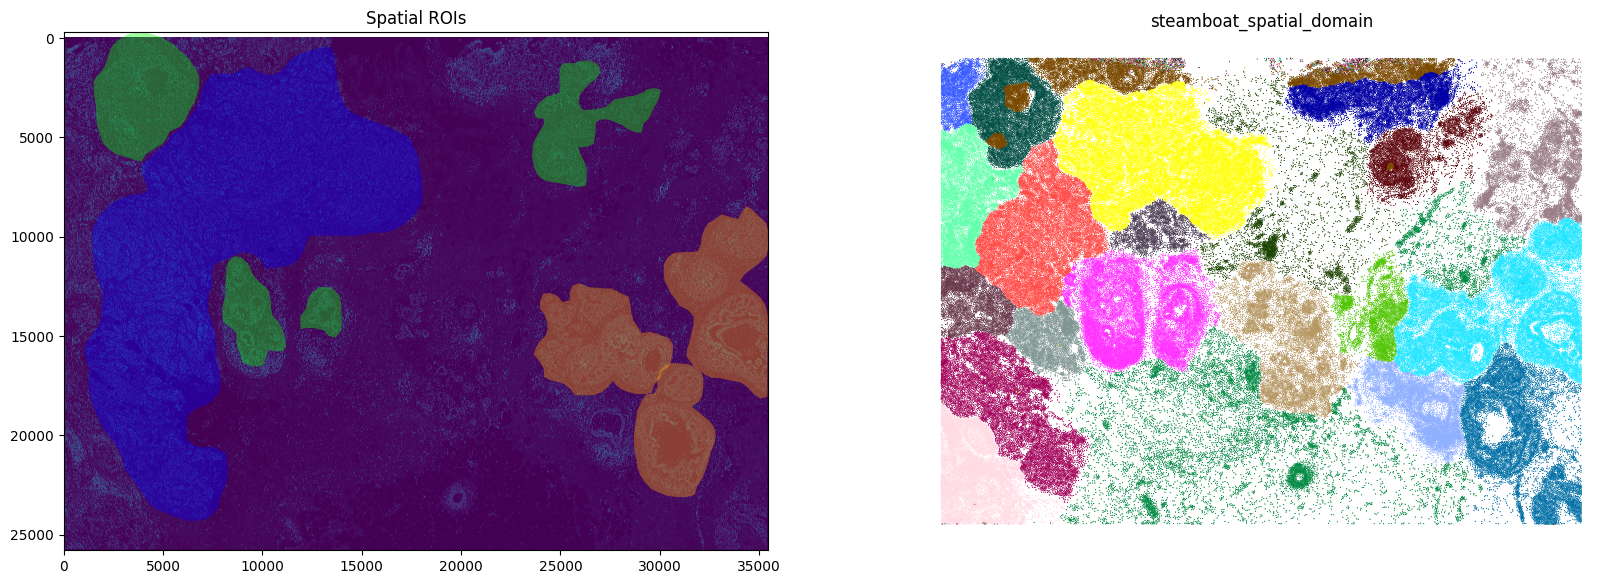

In [22]:
import spatialdata_plot
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()
sdata.pl.render_images(
    "morphology_focus"
    ).pl.render_shapes(
        "DCIS_1", color="#ffa50060"
        ).pl.render_shapes(
            "DCIS_2", color="#00ff0060"
            ).pl.render_shapes(
                "Invasive", color="#0000ff60"
                ).pl.show(
                    coordinate_systems="global", ax=axes[0], title='Spatial ROIs', colorbar=False
                    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_spatial_domain'], shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[1]
    )

In [ ]:
adatas[0].uns.pop('steamboat_spatial_domain_colors', None)

## Segmentation on ROIs

/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


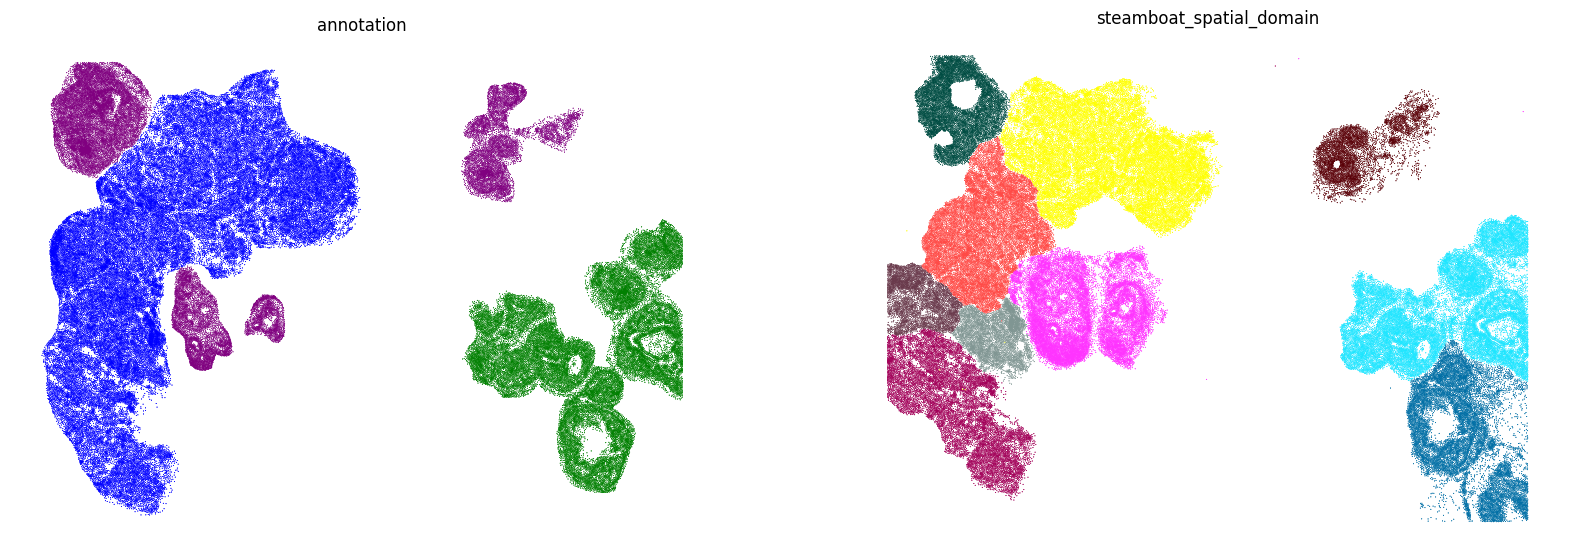

In [50]:
import spatialdata_plot
from matplotlib.colors import ListedColormap

cmap1 = ListedColormap(['green', 'purple', 'blue'])
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()
mask1 = adatas[0].obs['annotation'].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
sq.pl.spatial_scatter(
    adatas[0][mask1], color=['annotation'],
    palette=cmap1,
    shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[0]
    )
mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0', '1', '2', '3', '5', '6', '12', '15', '16', '17'])
sq.pl.spatial_scatter(
    adatas[0][mask2], color=['steamboat_spatial_domain'],
    shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[1]
    )

In [53]:
adatas[0].obs['cell_type_merged'] = adatas[0].obs['cell_type'].replace(
    {'Invasive_Tumor': 'Tumor', 'Prolif_Invasive_Tumor': 'Tumor'}
)

/tmp/ipython-input-4042335183.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adatas[0].obs['cell_type_merged'] = adatas[0].obs['cell_type'].replace(


### Noise

In [ ]:
## Noise
from sklearn.metrics import adjusted_rand_score

#mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
#mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['1','2','3','5','6','9'])
#common_mask = mask1 & mask2

ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "annotation"
label2 = "steamboat_spatial_domain"

df = adatas[0][common_mask].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
row_order = matched_rows.tolist() + unmatched_rows.tolist()
#row_order = matched_rows.tolist()
col_order = matched_cols.tolist() + unmatched_cols.tolist()
#col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised_ROIs")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()


### virchow

In [ ]:
##virchow
from sklearn.metrics import adjusted_rand_score

#mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
#mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0','3', '4', '5', '6', '7'])
#common_mask = mask1 & mask2

ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "annotation"
label2 = "steamboat_spatial_domain"

df = adatas[0][common_mask].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
row_order = matched_rows.tolist() + unmatched_rows.tolist()
#row_order = matched_rows.tolist()
col_order = matched_cols.tolist() + unmatched_cols.tolist()
#col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised_ROIs")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()


### UNI

In [75]:
##UNI
from sklearn.metrics import adjusted_rand_score

mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0', '1', '2', '3', '5', '6', '12', '15', '16', '17'])
common_mask = mask1 & mask2

In [76]:
ari = adjusted_rand_score(adatas[0][mask1].obs['cell_type_merged'].to_numpy(), adatas[0][mask1].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.2175656899958785


In [77]:
ari = adjusted_rand_score(adatas[0][mask2].obs['cell_type_merged'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.1994304914286249


In [78]:
ari = adjusted_rand_score(adatas[0][common_mask].obs['cell_type_merged'].to_numpy(), adatas[0][common_mask].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.2878369994207279


In [79]:
ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.1531544734319896


In [80]:
ari = adjusted_rand_score(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.3495415851533685


In [84]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("Mutual Information:", mi)

Mutual Information: 0.9278009593165266


In [88]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy

def normalized_vi(seg_true, seg_pred):
    seg_true = np.asarray(seg_true).ravel()
    seg_pred = np.asarray(seg_pred).ravel()

    # Encode string (or mixed) labels → integers
    le_true = LabelEncoder()
    le_pred = LabelEncoder()

    seg_true = le_true.fit_transform(seg_true)
    seg_pred = le_pred.fit_transform(seg_pred)

    # Mutual Information
    mi = mutual_info_score(seg_true, seg_pred)

    # Entropies
    H_true = entropy(np.bincount(seg_true) / len(seg_true))
    H_pred = entropy(np.bincount(seg_pred) / len(seg_pred))

    # Normalized VI
    return (H_true + H_pred - 2 * mi) / (H_true + H_pred)


In [91]:
vi = normalized_vi(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("VI:", vi)


VI: 0.46304510485089173


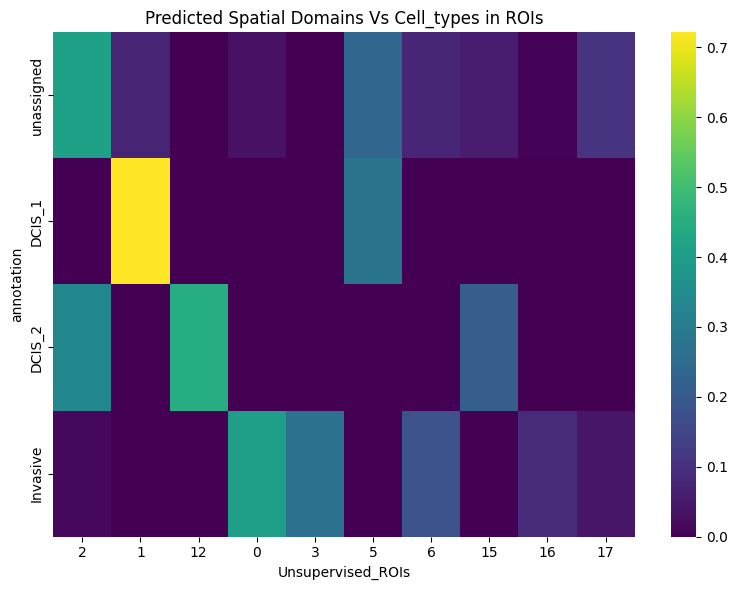

In [52]:
from scipy.optimize import linear_sum_assignment

label1 = "annotation"
label2 = "steamboat_spatial_domain"

df = adatas[0][mask2].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
row_order = matched_rows.tolist() + unmatched_rows.tolist()
#row_order = matched_rows.tolist()
col_order = matched_cols.tolist() + unmatched_cols.tolist()
#col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised_ROIs")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()


### h_optimus

In [ ]:
##h_optimus
from sklearn.metrics import adjusted_rand_score

#mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
#mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['1','2','3','4','6','7','8'])
#common_mask = mask1 & mask2

ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.21803817289420396


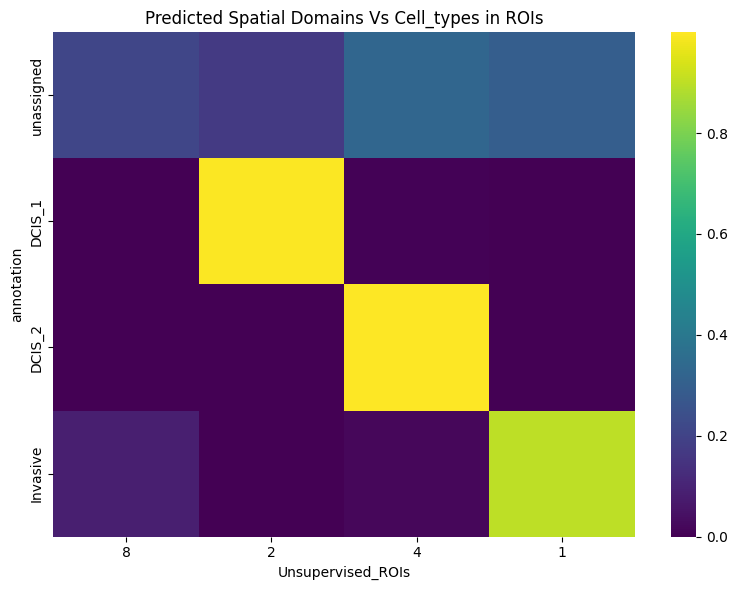

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "annotation"
label2 = "steamboat_spatial_domain"

df = adatas[0][common_mask].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
#row_order = matched_rows.tolist() + unmatched_rows.tolist()
row_order = matched_rows.tolist()
#col_order = matched_cols.tolist() + unmatched_cols.tolist()
col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised_ROIs")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()


### Error_Analysos

In [ ]:
## Error_Analysis
from sklearn.metrics import adjusted_rand_score

#mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
#mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0', '2', '3', '8'])
#common_mask = mask1 & mask2

ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.3466954218773028


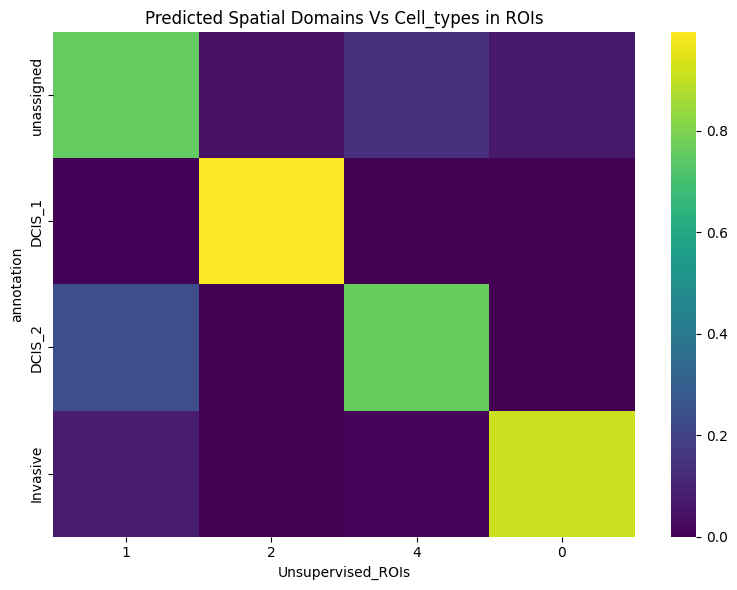

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "annotation"
label2 = "steamboat_spatial_domain"

df = adatas[0].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
#row_order = matched_rows.tolist() + unmatched_rows.tolist()
row_order = matched_rows.tolist()
#col_order = matched_cols.tolist() + unmatched_cols.tolist()
col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised_ROIs")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()


### Annotation

In [55]:
## Annotation
from sklearn.metrics import adjusted_rand_score

mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
mask2 = adatas[0].obs['annotation'].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
common_mask = mask1 & mask2

ari = adjusted_rand_score(adatas[0][common_mask].obs['cell_type_merged'].to_numpy(), adatas[0][common_mask].obs['annotation'].to_numpy())
print("ARI:", ari)

ARI: 0.35751549664158266


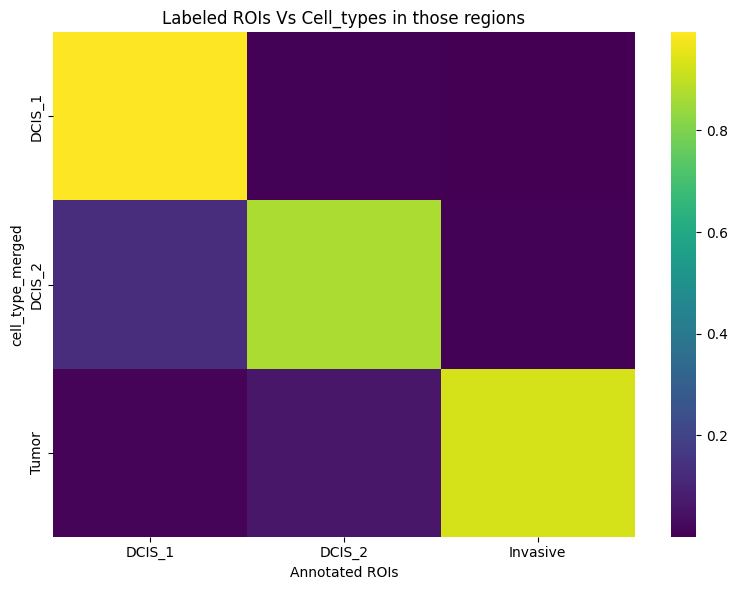

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "cell_type_merged"
label2 = "annotation"

df = adatas[0][common_mask].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
row_order = matched_rows.tolist() + unmatched_rows.tolist()
col_order = matched_cols.tolist() + unmatched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Annotated ROIs")
plt.ylabel(label1)
plt.title("Labeled ROIs Vs Cell_types in those regions")
plt.tight_layout()
plt.show()
